In [46]:
import numpy as np
import pandas as pd

df=pd.read_csv('tmdb_movies_dataset.csv')

In [47]:
# df.info()
df.head()
# df.describe()
# df.isna().sum()

,id,title,original_title,overview,release_date,popularity,vote_average,vote_count,genre_ids,original_language
0,1087192,How to Train Your Dragon,How to Train Your Dragon,"On the rugged isle of Berk, where Vikings and ...",2025-06-06,1075.8358,8.126,1013,"[14, 10751, 28]",en
1,1071585,M3GAN 2.0,M3GAN 2.0,After the underlying tech for M3GAN is stolen ...,2025-06-25,828.4871,7.711,376,"[28, 878, 53]",en
2,1315986,Man with No Past,Man with No Past,"Waking up in an unfamiliar city, a man with no...",2025-01-13,510.3027,6.775,20,"[28, 18]",en
3,1011477,Karate Kid: Legends,Karate Kid: Legends,"After a family tragedy, kung fu prodigy Li Fon...",2025-05-08,368.2810,7.254,478,"[28, 12, 18]",en
4,1061474,Superman,Superman,"Superman, a journalist in Metropolis, embarks ...",2025-07-09,359.1730,7.500,961,"[878, 12, 28]",en


In [48]:
# remove 'original_title' due to multilinguality
df=df.drop(columns=['original_title'])

df=df.dropna(subset=['release_date'])

# fill 'overview' with no description for later Naive Bayes classification
df['overview']=df['overview'].fillna("no description available.")

# convert 'release_date' to datetime for conversion
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Create separate columns for year, month, and day
df['release_year']=df['release_date'].dt.year
df['release_decade']=(df['release_year'] // 10) * 10
df['release_month']=df['release_date'].dt.month
df['release_day']=df['release_date'].dt.day

In [49]:
import ast

df['genre_ids'] = df['genre_ids'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Explode genre_ids so each genre becomes its own row
df=df.explode('genre_ids').reset_index(drop=True)

# one-hot encode
df=pd.get_dummies(df, columns=['genre_ids'], prefix='genre')

In [50]:
# popularity - severly max outlier, right-skewed
# vote_average - min & max outlier, left-skewed
# vote_count - severly imbalanced, right-skewed

# release_date - severely min outlier, severely left-skewed
# release_year - severely min outlier, severely left-skewed
# release_decade - min outlier, left-skewed

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

cols=['popularity', 'vote_average', 'vote_count']
categorical_cols=['genre_ids', 'original_language']
numerical_cols=['popularity', 'vote_average', 'vote_count']

# for col in cols:
    # sns.histplot(df[col], kde=True)
    # plt.title(f'Histplot - {col}')
    # plt.show()

    # sns.boxplot(df[col])
    # plt.title(f'Boxplot - {col}')
    # plt.show()

# sns.countplot(x='genre_ids', data=df_exploded, order=df_exploded['genre_ids'].value_counts().index)
# plt.title('Genre Frequency')
# plt.xlabel('Genre ID')
# plt.ylabel('Number of Movies')
# plt.xticks(rotation=45)
# plt.show()

In [52]:
for col in cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1

    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    min_value=df[col].min()
    max_value=df[col].max()

    if min_value < lower_bound or max_value > upper_bound:
        df[f'{col}_capped']=df[col].clip(lower=lower_bound, upper=upper_bound)

In [53]:
from scipy.stats import skew

cols_to_log=['popularity', 'vote_count']

for col in cols_to_log:
    skewness=skew(df[col])
    print(f"Skewness Before[{col}]: {skewness}")
    df[f'{col}_log'] = np.log1p(df[col])
    skewness=skew(df[f'{col}_log'])
    print(f"Skewness Now[{col}]: {skewness}")

Skewness Before[popularity]: 37.72590907922011
Skewness Now[popularity]: 0.9957278777390214
Skewness Before[vote_count]: 4.672318732019679
Skewness Now[vote_count]: -0.8019365438769556


In [54]:
df=pd.get_dummies(df, columns=['original_language'], drop_first=True)

In [55]:
df=df.drop(columns=['vote_average', 'popularity_capped', 'overview'], errors='ignore')
# df.head()

In [56]:
# corr=df.corr(numeric_only=True)
# plt.figure(figsize=(20, 14))
# sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
# plt.title('Feature Correlation Heatmap')
# plt.show()

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score

from catboost import CatBoostClassifier
from sklearn.multioutput import MultiOutputClassifier

# Drop problematic columns safely
df = df.drop(columns=['vote_average', 'popularity_capped', 'overview'], errors='ignore')

# Define target genre columns (multi-label classification)
genre_columns = [col for col in df.columns if col.startswith('genre_')]

# Separate X and y
X = df.drop(columns=genre_columns)
y = df[genre_columns]

# Drop non-numeric columns from X
non_numeric_cols = X.select_dtypes(include=['object']).columns
X = X.drop(columns=non_numeric_cols)

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

base_model=CatBoostClassifier(verbose=False, random_state=42)
model=MultiOutputClassifier(base_model)

model.fit(X_train, y_train)

predictions=model.predict(X_test)

accuracy=accuracy_score(y_test, predictions)

[ ACCURACY ]


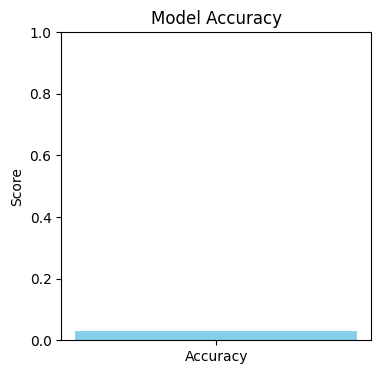

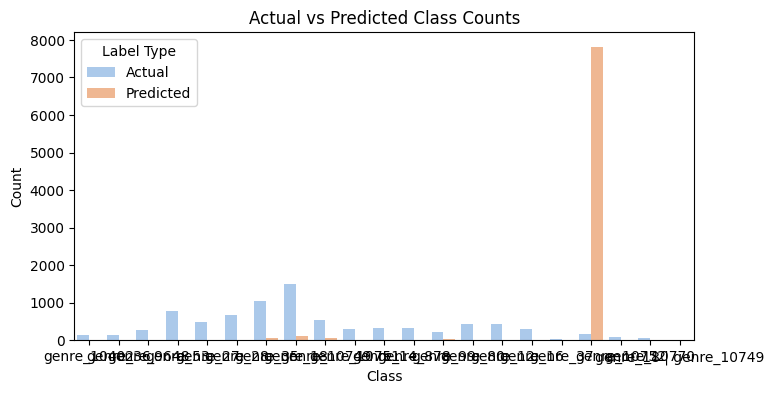

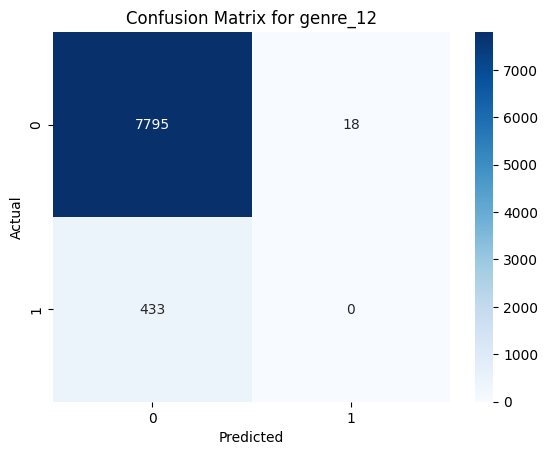

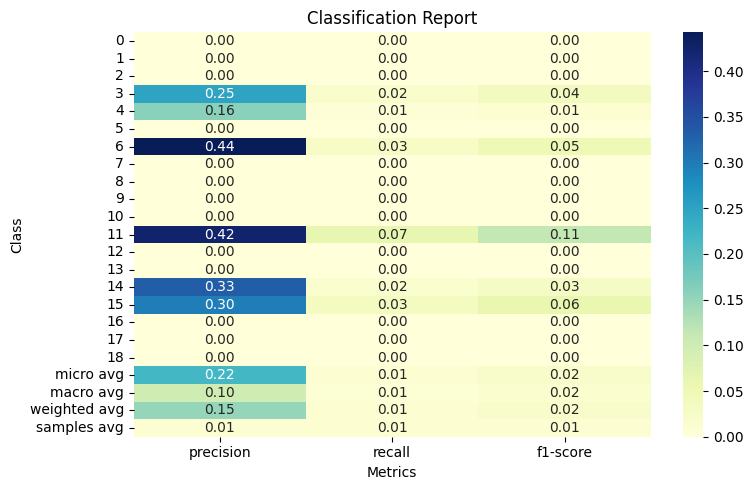

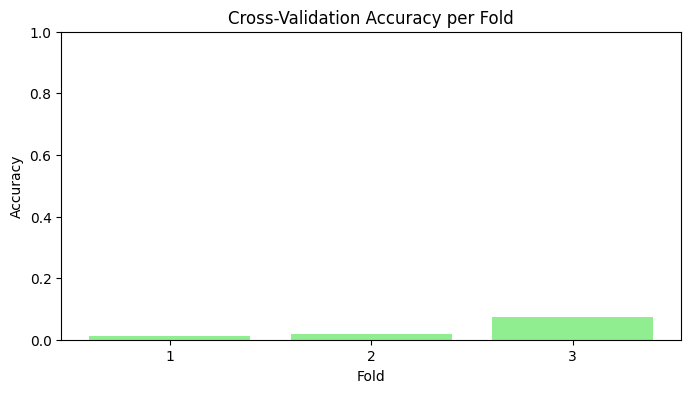

In [59]:
# 1. Accuracy - Bar Plot
print("[ ACCURACY ]")
plt.figure(figsize=(4, 4))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

# 2. Actual vs Predicted - Bar Chart
# Convert multi-hot vectors to string for display
y_test_labels = [' | '.join(y_test.columns[y_test.iloc[i]==1].tolist()) for i in range(len(y_test))]
pred_labels = [' | '.join(y_test.columns[predictions[i]==1].tolist()) for i in range(len(predictions))]

results_df = pd.DataFrame({
    'Actual': y_test_labels,
    'Predicted': pred_labels
})

plt.figure(figsize=(8, 4))
sns.countplot(
    x='value', hue='Type',
    data=pd.melt(results_df, value_vars=['Actual', 'Predicted'], var_name='Type'),
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap
from sklearn.metrics import multilabel_confusion_matrix

cm_per_genre = multilabel_confusion_matrix(y_test, predictions)

genre_idx = 0  # index of genre
sns.heatmap(cm_per_genre[genre_idx], annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix for {y_test.columns[genre_idx]}")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. Precision, Recall, F1 Score - Heatmap
report_df = pd.DataFrame(report)

# Remove 'accuracy' column if it exists
if 'accuracy' in report_df.columns:
    report_df = report_df.drop(columns=['accuracy'])
# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:3, :].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot
scores = cross_val_score(model, X, y, cv=3)
plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 4))
plt.show()